# Capstone: Define and Solve an ML Problem

In [49]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time
from sklearn.model_selection import GridSearchCV


**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [50]:
# File paths for both data sets
#census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(airbnb_filename)
df.head()

#df.columns

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the airbnb NYC Listing data set.
2. My label is price_category which determines whether the listing is high priced or not, binary classifying.
3. I plan to use features that give information about the private room,shared room,bedrooms, beds, bathrooms, price, etc. This is all information that I could clean and provide to my model to better determine whether a listing price is high or low.
4. This problem matters because using a model to predict whether a house is high or low priced can be created by Trove Analytics and platforms, property managers, and investment firms can gain information on which houses are in their price range and options for them to consider based on their needs.





## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [51]:
#1
#handling missing values
nan_count = np.sum(df.isnull(), axis=0)
nan_count


#indicates whether number of missing values is not zero
nan_detected = nan_count!=0
nan_detected


#can only replace missing values that are numeric with the mean
is_int_or_float = (df.dtypes == 'int64') | (df.dtypes == 'float64')
is_int_or_float

to_impute = nan_detected & is_int_or_float
to_impute

df.columns[to_impute]


#indicates whether number of missing values is not zero
nan_detected = nan_count!=0
nan_detected


#can only replace missing values that are numeric with the mean
is_int_or_float = (df.dtypes == 'int64') | (df.dtypes == 'float64')
is_int_or_float

to_impute = nan_detected & is_int_or_float
to_impute

df.columns[to_impute]






Index(['host_response_rate', 'host_acceptance_rate', 'bedrooms', 'beds'], dtype='object')

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

<AxesSubplot:>

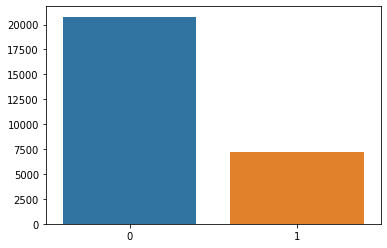

In [52]:
# YOUR CODE HERE
df['price_category'].value_counts()

df['price_category']=df['price_category'].map({'low':0, 'high':1})
y = df['price_category']
X = df.drop(columns = ['price_category','price'],axis=1)


sns.barplot(x=y.value_counts().index, y=y.value_counts().values)


### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

Information about mean, SD, max, etc.
       host_response_rate  host_acceptance_rate  host_listings_count  \
count        16179.000000          16909.000000         28022.000000   
mean             0.906901              0.791953            14.554778   
std              0.227282              0.276732           120.721287   
min              0.000000              0.000000             0.000000   
25%              0.940000              0.680000             1.000000   
50%              1.000000              0.910000             1.000000   
75%              1.000000              1.000000             3.000000   
max              1.000000              1.000000          3387.000000   

       host_total_listings_count  accommodates     bathrooms      bedrooms  \
count               28022.000000  28022.000000  28022.000000  25104.000000   
mean                   14.554778      2.874491      1.142174      1.329708   
std                   120.721287      1.860251      0.421132      0.700726   
m

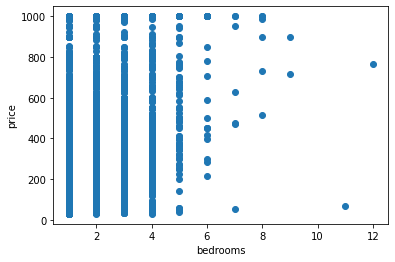

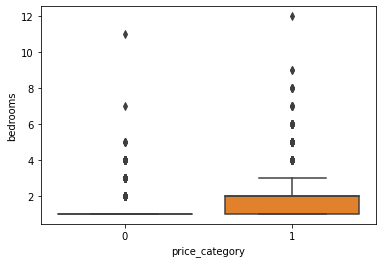

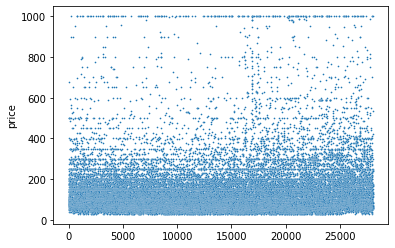

In [53]:
# YOUR CODE HERE
print("Information about mean, SD, max, etc.")
print(df.describe())

print("Columns that contain strings:")
print(df.select_dtypes(include=['object']).columns)

print("Columns that contain integers:")
print(df.select_dtypes(include=['int64']).columns)

print("Columns that contain floats:")
print(df.select_dtypes(include=['float64']).columns)

#Matplotlib
plt.scatter(df['bedrooms'], df['price'])
plt.xlabel('bedrooms')
plt.ylabel('price')
plt.show()

#Seaborn
sns.boxplot(x='price_category',y='bedrooms',data=df)
plt.show()
sns.scatterplot(x=df.index,y=df['price'],s=3)
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

After analyzing and exploring the data on the scatterplot of bedrooms against price I notice an outlier around 12 bedrooms with a price around 770. Another outlier I noticed is around 11 bedrooms priced just under 100. A majority of the data from 1-5 bedrooms the price spans the entire y axis up to 1000.


When analyzing the boxplot with price category and bedrooms, I notice that a majority of the data clusters around 2 bedrooms for those labeled high priced and a majority of the data clusters at  1 bedroom for the low price (0) boxplot. The property that has 2 or more bedrooms is likely an outlier for the low price category. The max bedrooms for a low priced label (upper whisker) falls less than the max bedrooms for a high priced label (3 vs. 1 bedroom)

Analyzing the scatterplot using sns, the x axis contains the data index which is the row numbers. All the rows cluster around 0-200 as the price and there are less and less data points the higher the pricing goes. There is a horizontal line formed by the data points at around 1000 which shows me that the prices are artifically stopped/capped at the 1000 price mark. 

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. Biases that could be present in my dataset could be that the results do not represent the entire housing market since the dataset only includes airbnb listings, so it should be clear that the results of this data should only be used for the client that needs information on airbnb listings. Features such as location and neighborhood could serve as proxies for protected characteristics such as socioeconomic status because location and neighborhoods can represent wealth.

2. The clients who are trying to determine which house to airbnb based on their personal affordability could be at risk. If the model predicts an airbnb price as high, the people who cannot afford higher priced airbnbs would be at more of a risk than those who get a prediction from the model as low priced and can afford it. The company would also be at risk because if the model is making false predictions, then platforms, property managers, etc. can be spreading false information.


## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [54]:
# YOUR CODE HERE

to_impute_selected = ['host_response_rate', 'host_acceptance_rate', 'bedrooms', 'beds']

for colname in to_impute_selected:
    df[colname +'_na'] = df[colname].isnull()

df.head()

for colname in to_impute_selected:
    df[colname].fillna(np.mean(df[colname]), inplace=True)
#checking:
for colname in to_impute_selected:
    print("{} missing values count :{}".format(colname, np.sum(df[colname].isnull(), axis = 0)))


#performing feature engineering techniques 
#such as one-hot encoding on categorical features (host location)

#checking which features to one hot encode
to_encode = list(df.select_dtypes(include=['object']).columns)       
df[to_encode].nunique()


print(df['neighbourhood_group_cleansed'].unique())

df_neighbor = pd.get_dummies(df['neighbourhood_group_cleansed'], prefix='neighbourhood_group_cleansed_')
#Concatenate DataFrame df with the one-hot encoded DataFrame df_room_type
df = df.join(df_neighbor)
#Remove the original column from DataFrame df
df.drop(columns = ['neighbourhood_group_cleansed','host_response_rate', 'host_acceptance_rate', 'bedrooms', 'beds'], inplace=True)


df




host_response_rate missing values count :0
host_acceptance_rate missing values count :0
bedrooms missing values count :0
beds missing values count :0
['Manhattan' 'Brooklyn' 'Queens' 'Staten Island' 'Bronx']


,name,description,neighborhood_overview,host_name,host_location,host_about,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,...,price_category,host_response_rate_na,host_acceptance_rate_na,bedrooms_na,beds_na,neighbourhood_group_cleansed__Bronx,neighbourhood_group_cleansed__Brooklyn,neighbourhood_group_cleansed__Manhattan,neighbourhood_group_cleansed__Queens,neighbourhood_group_cleansed__Staten Island
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,True,8.0,8.0,True,...,0,False,False,True,False,0,0,1,0,0
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,True,1.0,1.0,True,...,0,False,False,False,False,0,1,0,0,0
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",True,1.0,1.0,True,...,1,False,False,False,False,0,1,0,0,0
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,True,1.0,1.0,True,...,0,False,False,False,False,0,0,1,0,0
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,True,1.0,1.0,True,...,0,True,True,False,False,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28017,Astoria Luxury suite 2A,THIS LOVELY HOME IS THE SPACIOUS SUITE WITH PR...,NaN,Vicky,"Queens, New York, United States",NaN,True,8.0,8.0,True,...,0,False,False,False,False,0,0,0,1,0
28018,Newly renovated suite in the heart of Williams...,Just fully renovated from head to toe. On the ...,NaN,Samuel,"New York, New York, United States","Hello, my name is Sam. I am a real estate prof...",True,0.0,0.0,True,...,1,False,False,False,False,0,1,0,0,0
28019,Perfect Room to Stay in Brooklyn! Near Metro!,"Amazing and comfortable space in Brooklyn, sam...",NaN,Carlos,US,NaN,True,6.0,6.0,True,...,0,False,False,False,False,0,1,0,0,0
28020,New Beautiful Modern One Bedroom in Brooklyn,This stylish place to stay is perfect for a gr...,NaN,Lexia,"New York, New York, United States","I am a graphic designer, swell chaser and duri...",True,3.0,3.0,True,...,0,False,False,False,False,0,1,0,0,0


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

Handling missing values:
To prepare my data, I first identified columns with missing values and selected numerical features (host_response_rate, host_acceptance_rate, bedrooms, beds) to impute.

I then replaced the missing numerical values with the mean of each feature. That way I could use the features without losing that data.

Performing feature engineering using one hot encoding:
I converted the neighbourhood_group_cleansed into many binary columns. I needed to do this so that learning models (Decision Tree) can process the data since it was categorical and now 0s and 1s. I then removed the original categorical column. 

Selecting/removing features from my dataset:
I removed the price_category and price features since price category is the variable that the model is predicting and price has an influence on it as well.

I kept the features that relate the property characteristics, host info, and location since they may provide useful information for predicting if a listing is high or low priced.

Prepared data for modeling:
I converted the target variable price_category from categorical labels of high, low into numerical labels (0,1) so that it could be used for the training data easily.

I split the dataset into training and testing sets by using the train_test_split() function. 

I removed the text columns that remained since decision tree take in numerical inputs.

I chose the Decision Tree model.


## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [55]:
# Create labeled examples from the dataset
# YOUR CODE HERE


y = df['price_category']
X = df.drop(columns = ['price_category','price'],axis=1)



In [56]:
# Create training and test sets out of the labeled examples 
# YOUR CODE HERE

#creating training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33,random_state=123)

#dropping all columns with text
X_train = X_train.select_dtypes(exclude='object')
X_test = X_test.select_dtypes(exclude='object')



print("X train data: ")
# for colname in X_train.columns:
#    print("{} missing values count :{}".format(colname, np.sum(df[colname].isnull(), axis = 0)))

print("X test data: ")
print(X_test)

#print("y train data: ")
#print(y_train)
print("y test data: ")
print(y_test)


X train data: 
X test data: 
       host_is_superhost  host_listings_count  host_total_listings_count  \
12389               True                  3.0                        3.0   
704                 True                  1.0                        1.0   
2259                True                  1.0                        1.0   
27932               True                  1.0                        1.0   
12888               True                  1.0                        1.0   
...                  ...                  ...                        ...   
2053                True                  1.0                        1.0   
23270               True                  1.0                        1.0   
18482               True                  1.0                        1.0   
25955               True                 10.0                       10.0   
2910                True                  1.0                        1.0   

       host_has_profile_pic  host_identity_verified  accom

Max Depth=2, accuracy score: 0.7897923875432526
Max Depth=4, accuracy score: 0.8080666089965398
Max Depth=10, accuracy score: 0.8309904844290658
Max Depth=20, accuracy score: 0.8015787197231834
Max Depth=32, accuracy score: 0.7961721453287197
Max Depth=40, accuracy score: 0.792711937716263


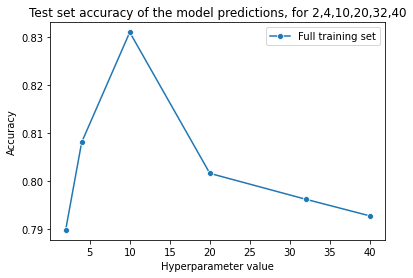

In [9]:
# Train, test and evaluate your model
# YOUR CODE HERE


#2
#Decision Tree

def train_test_DT(X_train, X_test, y_train, y_test, depth, leaf=1,crit='entropy'):
    model = DecisionTreeClassifier(criterion = crit, max_depth = depth,min_samples_leaf = leaf)
    model.fit(X_train, y_train)
    class_label_predictions = model.predict(X_test)
    acc_score = accuracy_score(y_test, class_label_predictions)
    return acc_score


accuracy_list = []
max_depth_range = [2,4,10,20,32,40]
for md in max_depth_range:
    score = train_test_DT(X_train, X_test, y_train, y_test, md)
    print('Max Depth=' + str(md) + ', accuracy score: ' + str(score))
    accuracy_list.append(float(score))


    
def visualize_accuracy(hyperparam_range, acc):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    p = sns.lineplot(x=hyperparam_range, y=acc, marker='o', label = 'Full training set')
    plt.title('Test set accuracy of the model predictions, for ' + ','.join([str(h) for h in hyperparam_range]))
    ax.set_xlabel('Hyperparameter value')
    ax.set_ylabel('Accuracy')
    plt.show()

visualize_accuracy(max_depth_range, accuracy_list)

    


In [57]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE

md = [2**n for n in range(2,6)]
msl = [25*2**n for n in range(0,3)]
param_grid={'max_depth':md, 'min_samples_leaf':msl}

param_grid

model = DecisionTreeClassifier()
model.fit(X_train,y_train)
# 2. Run a Grid Search with 5-fold cross-validation using our the model.
#   Pass all relevant parameters to GridSearchCV and assign the output to the object 'grid'
grid = GridSearchCV(model, param_grid, cv=5)

# 3. Fit the model to the training data and assign the fitted model to the 
#    variable grid_search
grid_search = grid.fit(X_train, y_train)

print('Done')


best_md = grid_search.best_estimator_.max_depth
best_msl = grid_search.best_estimator_.min_samples_leaf

# Print best performing hyperparameter configuration
print('Best value for max depth: {0}'.format(best_md))
print('Best value for the minimum number of samples required to be at a leaf node: {0}'
      .format(best_msl))

# Print best accuracy score resulting from this configuration
print('Accuracy score: {0}'.format(grid_search.best_score_))


Done
Best value for max depth: 16
Best value for the minimum number of samples required to be at a leaf node: 100
Accuracy score: 0.8273146442285796


In [58]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
# YOUR CODE HERE
train_test_DT(X_train, X_test, y_train, y_test, 16, leaf=100,crit='entropy')


0.8308823529411765

In [59]:
# Interpret your model's outputs 
# YOUR CODE HERE
feature_imp = model.feature_importances_

#2. Create a Pandas DataFrame with a list of all features and their scores. 
df_features = pd.DataFrame({'name':X_train.columns.values, 'imp':feature_imp})

#3. Sort df_features in descending order
df_sorted = df_features.sort_values(by='imp',ascending=False)

#4. the top 5 sorted feature names and save the result to list 'top_five' 

top_five = df_sorted.iloc[:5]['name'].tolist()
print('Top five features: {0}'.format(top_five))

Top five features: ['accommodates', 'reviews_per_month', 'bathrooms', 'number_of_reviews', 'review_scores_location']


In [60]:

dt_model = DecisionTreeClassifier(criterion = 'entropy',max_depth=16, min_samples_leaf=100)
dt_model.fit(X_train,y_train)
dt_predict = dt_model.predict(X_test)

dt_accuracy = train_test_DT(X_train, X_test, y_train, y_test, 16, leaf=1,crit='entropy')


dt_f1 = f1_score(y_test,dt_predict)

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose the decision tree model because my label, price_category is binary categorical. Decision Trees work well for classification problems and they are simpler to interpret. 


2. I used gridsearch to figure out which values for the max depth and min samples per leaf produced the best performance from the model and got that a max depth of 16 and min of 100 samples per leaf give the best performance.

3. The feature importances are the features that had the biggest influence on the predictions of the decision tree. Accommodates being the most important feature in determining whether a listing was predicted to be low or high priced. Next the reviews per month and so on.

4. A ethical concern is that the model could make incorrect predictions that influence the decision of the customers searching for listings on Airbnb. This AI model and its decisions should be used just for support on customers making a decision but should not be the only factor in making decisions as it can get information wrong.


---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [61]:
# Scale your data for the neural network


# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [62]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
# YOUR CODE HERE

input_layer = keras.layers.InputLayer(input_shape=(X_train.shape[1],))
nn_model.add(input_layer)


# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.

# I am choosing to do 2 layers because 2 layers would be enough for the
#neural network to learn the nonlinear relationship. I am starting off with 32 units 
#then 16 because those are commonly used and not too complicated for the model but 
#great values to hopefully not cause overfitting. I chose the relu activation 
#function because it is standard for hidden layers. The activation function for the output
#layer is sigmoid becuase it will produce a probability between 0-1 which is beneficial for our 
#binary classification problem.

    # Create the first hidden layer 
hidden_layer_1 = keras.layers.Dense(units=32, activation='relu')
nn_model.add(hidden_layer_1)

    # Create the second hidden layer and add it to the model object:
hidden_layer_2 = keras.layers.Dense(units=16, activation='relu')
nn_model.add(hidden_layer_2)



# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
# YOUR CODE HERE

output_layer = keras.layers.Dense(units=1, activation='sigmoid')
nn_model.add(output_layer)


# Print a summary of your model
nn_model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_9 (Dense)              (None, 32)                1472      
_________________________________________________________________
dense_10 (Dense)             (None, 16)                528       
_________________________________________________________________
dense_11 (Dense)             (None, 1)                 17        
Total params: 2,017
Trainable params: 2,017
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [63]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

# I chose a learning rate of 0.1 because it allows the model to make updates
# to the weights while also balancing the speed so that it does not take too long to train

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.1)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [64]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [65]:
# YOUR CODE HERE
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [66]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [67]:
# Decision: How many epochs? Add a comment.
#I started off with 100 epochs because that is a big enough value to update the weights and learn the data, 
#but also not too big where the neural network will start to overfit and memorize the data.

column_names = X_train.select_dtypes(bool).columns
X_train[column_names] = X_train[column_names].astype(float)


t0 = time.time() # start time

num_epochs =  20

history = nn_model.fit(X_train_scaled,y_train,epochs=num_epochs,validation_split=0.2, verbose=0, callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)],)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 20], Loss: 0.3696, Accuracy: 0.8353, Val_loss: 0.3873, Val_accuracy: 0.8352
Epoch [10/ 20], Loss: 0.3528, Accuracy: 0.8395, Val_loss: 0.3683, Val_accuracy: 0.8407
Epoch [15/ 20], Loss: 0.3411, Accuracy: 0.8463, Val_loss: 0.3724, Val_accuracy: 0.8309
Epoch [20/ 20], Loss: 0.3346, Accuracy: 0.8503, Val_loss: 0.3636, Val_accuracy: 0.8415
Elapsed time: 31.03s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



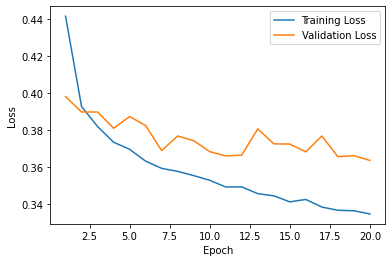

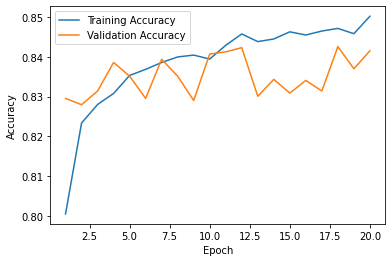

In [68]:
history.history.keys()

# Plot training loss and validation loss over epochs
# YOUR CODE HERE

plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()




# Plot training accuracy and validation accuracy over epochs
# YOUR CODE HERE
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [69]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

# YOUR CODE HERE
#print("y_train: ", y_train.dtypes)
#print("y_test: ", y_test.dtypes)

column_names = X_test.select_dtypes(bool).columns
X_test[column_names] = X_test[column_names].astype(float)

#print("X_test: ", X_test.dtypes)


loss, accuracy = nn_model.evaluate(X_test_scaled, y_test)

probability_predictions = nn_model.predict(X_test)
class_label_predictions=[]
for i in range(0,len(y_test)):
    if probability_predictions[i] >= 0.5:
        class_label_predictions.append(1)
    else:
        class_label_predictions.append(0)



289/289 [==============================] - 1s 2ms/step - loss: 0.3676 - accuracy: 0.8442


In [70]:
# Compute accuracy and F1 score for the neural network and print the results

accuracy = accuracy_score(y_test, class_label_predictions)
print(accuracy)
f1 = f1_score(y_test, class_label_predictions)
print(f1)


0.314878892733564
0.38806258450840253


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I am choosing to do 2 layers because 2 layers would be enough for the neural network to learn the nonlinear relationship. I am starting off with 32 units then 16 because those are commonly used and not too complicated for the model but great values to hopefully not cause overfitting. I chose the relu activation function because it is standard for hidden layers. The activation function for the output layer is sigmoid becuase it will produce a probability between 0-1 which is beneficial for our binary classification problem. I chose to do 20 epoches because more than that would cause overfitting because the more epoches the more the neural network will change the weights and continue adjusting to memorize this specific data. 20 was around the right number of epoches because thats where the accuracy starting stabilizing.
2. On my training curve, the training and validation loss stayed pretty stable throughout training. There is a small gap between the training and validation accuracy which could indicated slight overfitting. 
3. The accuracy is 0.61, the F1 score is 0.38. This is a surprise because I expected the values to be higher than that. This suggests that the model did not generalize to the test data as well as it did to the validation data.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [71]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
# YOUR CODE HERE

results = pd.DataFrame({
     'Metric': ['Accuracy', 'F1 Score'],
     'Decision Tree': [dt_accuracy, dt_f1],
     'Neural Network': [accuracy, f1] 
})
print(results.to_string(index=False))


   Metric  Decision Tree  Neural Network
 Accuracy       0.808715        0.314879
 F1 Score       0.613254        0.388063


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. The decision tree model performed better than the neural network model on both the evaluation metrics. The decision tree got an accuracy of 0.808 whereas the neural network had an accuracy of 0.610. F1 score of the decision tree was 0.613 whereas the neural network had an f1 score of 0.376. Both the accuracy and F1 score improved with the Decision Tree whereas neither that F1 or accuracy metrics were high for the neural network.

2. The added complexity of building a neural network was not worth it in this case. The neural networks tend to be more powerful but do require more effort to train. The decision tree happened to provide a better accuracy and F1 score and was more effective for this problem.

3. If I was presenting to the company and the clients I would recommend deploying the Decision Tree model. It achieved a better performance on both of the evaluation metrics. The higher accuracy and F1 score reduced the chance that the model would make incorrect predictions. This would be the most reliable choice for helping the clients identify the listings that fit what they need.

4. If I had more time I would try out different neural network parts such as adjusting the hidden layers, units, learning rate, number of epoches, etc. 


---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. For the .map part I used AI to ask what the function was that converted the column to a binary numeric label (0s and 1s) because I remmeber doing that in an earlier assignment but could not recall to use the .map function. I used it as a reminder for functions I knew I used in previous activities but could not recall the exact names.

2. For the EDA I had trouble figuring out which function to use for analyzing class imbalance. I knew that I wanted to make a histogram but was unsure on how to get the values. I asked other fellows in my lab section to better understand how to approach this part. 
3. I verified my work was correct in lab section.

4. Next time, I would try to get through most of the work prior to my lab session so that I could ask my group more questions on parts of the project. 
